In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

In [2]:
PRECIOS    = [500,  700,  300,  800,  400]
CANTIDADES = [5,    6,    10,   3,    7  ]
REND       = [0.15, 0.05, 0.03, 0.10, 0.10]
 
CAPITAL    = 10_000
N_BONOS    = len(PRECIOS)


In [3]:
def rendimiento_total(individuo):
    """
    Calcula el rendimiento total de una cartera.
    El cromosoma es una lista de enteros: cantidad de bonos a comprar de cada tipo.
    Si el costo supera el capital disponible, se penaliza la aptitud.
    """
    costo = sum(individuo[i] * PRECIOS[i] for i in range(N_BONOS))
    if costo > CAPITAL:
        return (-1.0,)  
    rendimiento = sum(individuo[i] * PRECIOS[i] * REND[i] for i in range(N_BONOS))
    return (rendimiento,)


In [6]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
 
toolbox = base.Toolbox()
 
def gen_individuo():
    return [random.randint(0, CANTIDADES[i]) for i in range(N_BONOS)]
 
toolbox.register("individual", tools.initIterate,
                 creator.Individual, gen_individuo)
toolbox.register("population", tools.initRepeat,
                 list, toolbox.individual)
 
toolbox.register("evaluate", rendimiento_total)
toolbox.register("mate",     tools.cxUniform, indpb=0.5)
toolbox.register("mutate",   tools.mutUniformInt,
                 low=0, up=CANTIDADES, indpb=0.2)
toolbox.register("select",   tools.selTournament, tournsize=3)


In [7]:
random.seed(42)
np.random.seed(42)
 
POP_SIZE   = 100
N_GEN      = 200
CXPB       = 0.8
MUTPB      = 0.2
 
poblacion = toolbox.population(n=POP_SIZE)
hof       = tools.HallOfFame(1)
 
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", np.max)
stats.register("avg", np.mean)
 
_, log = algorithms.eaSimple(
    poblacion, toolbox,
    cxpb=CXPB, mutpb=MUTPB,
    ngen=N_GEN, stats=stats,
    halloffame=hof, verbose=False
)


In [8]:
mejor = hof[0]
costo_total = sum(mejor[i] * PRECIOS[i] for i in range(N_BONOS))
rend_total  = sum(mejor[i] * PRECIOS[i] * REND[i] for i in range(N_BONOS))
 
print("=" * 45)
print("       CARTERA ÓPTIMA ENCONTRADA")
print("=" * 45)
nombres = ['A', 'B', 'C', 'D', 'E']
for i in range(N_BONOS):
    inv = mejor[i] * PRECIOS[i]
    r   = inv * REND[i]
    print(f"  Bono {nombres[i]}: {mejor[i]:2d} unidades  |  "
          f"Inversión: ${inv:>6,}  |  Rendimiento: ${r:>6.0f}")
print("-" * 45)
print(f"  Costo total   : ${costo_total:>8,}")
print(f"  Capital disp. : ${CAPITAL:>8,}")
print(f"  Capital restante: ${CAPITAL - costo_total:>6,}")
print(f"  Rendimiento total: ${rend_total:>6.2f}")
print("=" * 45)


       CARTERA ÓPTIMA ENCONTRADA
  Bono A:  5 unidades  |  Inversión: $ 2,500  |  Rendimiento: $   375
  Bono B:  3 unidades  |  Inversión: $ 2,100  |  Rendimiento: $   105
  Bono C:  0 unidades  |  Inversión: $     0  |  Rendimiento: $     0
  Bono D:  3 unidades  |  Inversión: $ 2,400  |  Rendimiento: $   240
  Bono E:  7 unidades  |  Inversión: $ 2,800  |  Rendimiento: $   280
---------------------------------------------
  Costo total   : $   9,800
  Capital disp. : $  10,000
  Capital restante: $   200
  Rendimiento total: $1000.00


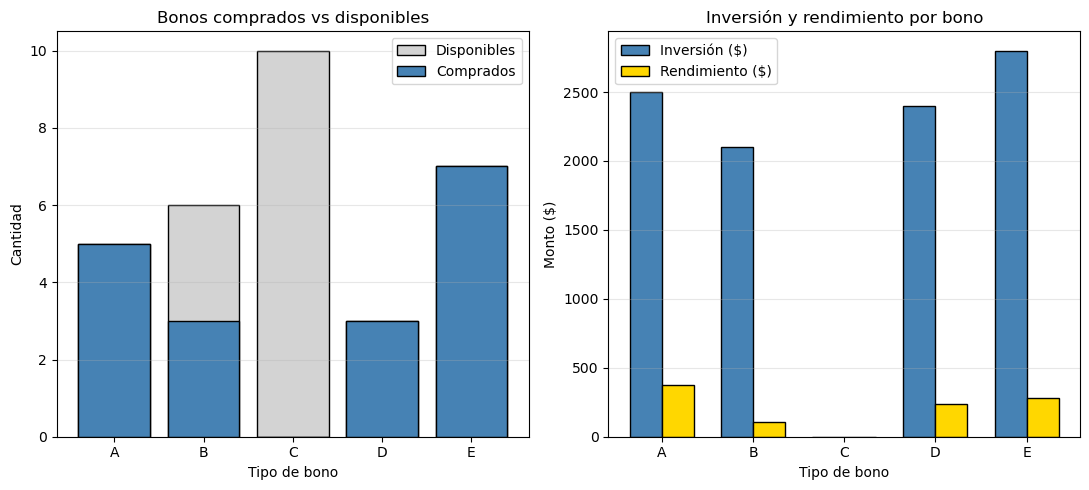

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Gráfica 1: bonos comprados vs disponibles
axes[0].bar(nombres, CANTIDADES, color='lightgray', edgecolor='black', label='Disponibles')
axes[0].bar(nombres, mejor, color='steelblue', edgecolor='black', label='Comprados')
axes[0].set_xlabel('Tipo de bono')
axes[0].set_ylabel('Cantidad')
axes[0].set_title('Bonos comprados vs disponibles')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Gráfica 2: inversión y rendimiento por tipo
inversiones  = [mejor[i] * PRECIOS[i] for i in range(N_BONOS)]
rendimientos = [mejor[i] * PRECIOS[i] * REND[i] for i in range(N_BONOS)]
x_pos = np.arange(N_BONOS)
ancho = 0.35

axes[1].bar(x_pos - ancho/2, inversiones,  ancho, color='steelblue', edgecolor='black', label='Inversión ($)')
axes[1].bar(x_pos + ancho/2, rendimientos, ancho, color='gold',      edgecolor='black', label='Rendimiento ($)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(nombres)
axes[1].set_xlabel('Tipo de bono')
axes[1].set_ylabel('Monto ($)')
axes[1].set_title('Inversión y rendimiento por bono')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()